# HyDE (Hypothetical Document Embedding) 실험

HyDE(Hypothetical Document Embeddings)는 **사용자 질문에 대해 LLM(대형 언어 모델)로 가상의 문서를 먼저 생성하고, 이 문서를 임베딩하여 검색하는 방식**이다.  
기존에는 질문 자체를 임베딩해 유사한 문서를 찾았지만, HyDE는 질문의 맥락과 의도를 더 잘 반영할 수 있는 가상 문서를 생성해 임베딩하고, 이를 벡터 DB에서 비교함으로써 **더 정확한 검색 결과**를 얻을 수 있다.

**핵심 요약**
- 질문 → LLM이 가상 문서 생성 → 임베딩 → 벡터 DB에서 유사도 검색
- 기존 방식보다 **질문의 의미와 맥락을 더 잘 반영**하여 검색 정확도 향상
- RAG 등 다양한 검색·생성 AI 시스템에서 활용 가능
- 단점: LLM 사용으로 **속도가 느려질 수 있음**

In [1]:
%pip install -Uq python-dotenv langchain langchain-openai langchain-pinecone kiwipiepy rank_bm25 scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://eu.api.smith.langchain.com'
os.environ['LANGSMITH_API_KEY'] = os.getenv('langsmith_key')
os.environ['LANGSMITH_PROJECT'] = 'skn23-langchain'
os.environ['OPENAI_API_KEY'] = os.getenv("openai_key")
os.environ['PINECONE_API_KEY'] = os.getenv("pinecone_key")

## 데이터 준비

In [3]:
import pandas as pd

documents_df = pd.read_csv('documents.csv')
queries_df = pd.read_csv('queries.csv')

## BM25

In [4]:
# BM25 키워드 검색 모델
# - 문서를 토큰화해서 BM25모델 생성
# - 검색어도 동일하게 토큰화한 이후 BM25 검색

from rank_bm25 import BM25Okapi
from kiwipiepy import Kiwi

kiwi = Kiwi()

def kiwi_tokenize(doc):
    return [token.form for token in kiwi.tokenize(doc)]

tokenized_docs = [kiwi_tokenize(doc) for doc in documents_df['content']]
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=5):
    query_tokens = kiwi_tokenize(query)
    # print(query_tokens)
    scores = bm25.get_scores(query_tokens) # 30개의 문서에 대한 bm25 점수
    # print(scores)

    ranked_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    retrieved_docs = [documents_df['doc_id'].iloc[i] for i in ranked_idx[:top_k]]
    return retrieved_docs

bm25_search('제주도 관광 명소')

['D1', 'D2', 'D3', 'D4', 'D5']

## 벡터 서치

In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

embedding_model = OpenAIEmbeddings()
vector_store = PineconeVectorStore(
    index_name='ir',
    embedding=embedding_model
 )

c:\Users\Playdata\nlp\nlp_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## HyDE Chain

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model('gpt-4.1-mini', temperature=0.3)
prompt = PromptTemplate.from_template('''
질문: {query}

위 질문에 대해서 실제 문서가 아니어도 좋으니, 답변을 생성하세요.
''')
output_parser = StrOutputParser()

hyde_chain = prompt | llm | output_parser
print(hyde_chain.invoke('제주도 관광 명소'))

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


제주도는 아름다운 자연경관과 독특한 문화가 어우러진 한국의 대표적인 관광지입니다. 제주도에서 꼭 방문해볼 만한 관광 명소를 몇 가지 소개합니다.

1. 한라산 국립공원  
제주의 상징인 한라산은 한국에서 가장 높은 산으로, 등산과 자연 탐방을 즐기기에 최적의 장소입니다. 특히 봄철 진달래와 가을 단풍이 아름답기로 유명합니다.

2. 성산일출봉  
일출 명소로 유명한 성산일출봉은 해발 182m의 화산 분화구로, 정상에 올라가면 동해와 제주 동부 해안의 멋진 경관을 감상할 수 있습니다.

3. 만장굴  
세계에서 가장 긴 용암동굴 중 하나인 만장굴은 신비로운 지하 동굴 탐험을 할 수 있는 곳입니다. 다양한 용암 지형과 종유석을 관찰할 수 있습니다.

4. 천지연 폭포  
제주도 남쪽에 위치한 천지연 폭포는 22m 높이에서 떨어지는 폭포수와 주변의 울창한 숲이 어우러져 아름다운 풍경을 자아냅니다.

5. 우도  
제주 본섬에서 배로 15분 거리에 있는 우도는 조용하고 평화로운 섬으로, 자전거 투어와 해변 산책을 즐기기에 좋습니다.

6. 제주 민속촌  
제주의 전통 가옥과 생활 문화를 체험할 수 있는 민속촌에서는 제주 사람들의 옛 생활 모습을 엿볼 수 있습니다.

이 외에도 협재 해수욕장, 섭지코지, 용두암 등 다양한 명소들이 있어 제주도 여행을 더욱 풍성하게 만들어 줍니다. 계절과 취향에 맞춰 다양한 코스를 계획해보세요!


In [7]:
# HyDE 가상답변
import time
from tqdm.auto import tqdm

hyde_pseudo = {}

for idx, row in tqdm(queries_df.iterrows()):
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = hyde_chain.invoke(query_text)
    hyde_pseudo[qid] = pseudo_answer    # qui 키에 가상답변 값 저장
    time.sleep(0.5) # api 과호출 방지용

hyde_pseudo

0it [00:00, ?it/s]Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
1it [00:07,  7.86s/it]Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2it [00:14,  7.27s/it]Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
3it [00:18,  5.73s/it]Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: 

{'Q1': '제주도 올레길 트레킹 코스를 추천해드릴게요!\n\n1. **올레길 7코스 (월평-외돌개)**  \n   제주 올레길 중에서도 경치가 아름답기로 유명한 코스입니다. 바다를 따라 걷는 구간이 많아 시원한 바람과 푸른 바다를 만끽할 수 있어요. 외돌개 바위와 송악산 전망대도 들러보시면 좋습니다.\n\n2. **올레길 10코스 (쇠소깍-남원)**  \n   쇠소깍의 맑은 물과 제주 전통 마을의 풍경을 함께 즐길 수 있는 코스입니다. 강과 바다가 만나는 독특한 자연 경관이 인상적이며, 중간중간 카페나 식당도 있어 휴식하기 좋아요.\n\n3. **올레길 1코스 (시흥-광치기 해변)**  \n   제주 올레길의 시작점으로, 제주 바다와 오름(작은 화산체)을 함께 감상할 수 있는 코스입니다. 광치기 해변의 투명한 바닷물과 성산일출봉의 멋진 풍경이 하이라이트입니다.\n\n4. **올레길 6코스 (쇠소깍-외돌개)**  \n   자연과 해안 절경을 동시에 즐길 수 있는 코스로, 해안선을 따라 걷는 구간이 많아 트레킹 내내 바다 풍경이 끊이지 않습니다. 특히 해질 무렵에 걷기 좋습니다.\n\n---\n\n**팁**  \n- 올레길은 코스마다 난이도와 거리 차이가 있으니, 자신의 체력과 일정에 맞게 선택하세요.  \n- 편안한 트레킹화를 신고, 물과 간단한 간식을 준비하는 것이 좋습니다.  \n- 제주도의 날씨는 변덕스러우니, 우비나 방풍 자켓도 챙기세요.\n\n즐거운 제주 올레길 트레킹 되시길 바랍니다!',
 'Q2': '전주 비빔밥과 진주 비빔밥은 모두 한국을 대표하는 전통 비빔밥이지만, 재료 구성과 맛에서 차이가 있습니다.\n\n1. 전주 비빔밥  \n- 재료: 전주 비빔밥은 다양한 나물과 고기, 계란, 고추장 등이 풍부하게 들어갑니다. 대표적으로 고사리, 도라지, 시금치, 콩나물, 애호박, 무, 고기(주로 소고기), 계란 프라이 또는 날계란, 김, 그리고 참기름이 사용됩니다.  \n- 특징 및 맛: 재료가 다양하고 신선하며, 고기의 감칠맛과 고추장의 매콤달콤한 

In [8]:
# 질문/가상답변 확인
import pandas as pd

pd.set_option('display.max_colwidth', None)

hyde_df = pd.DataFrame({
    'query_id': list(hyde_pseudo.keys()),
    'query_text': queries_df['query_text'],
    'pseudo_answer': list(hyde_pseudo.values())

})
hyde_df.head()

,query_id,query_text,pseudo_answer
0,Q1,제주도 올레길 트레킹 코스 추천,"제주도 올레길 트레킹 코스를 추천해드릴게요!\n\n1. **올레길 7코스 (월평-외돌개)** \n 제주 올레길 중에서도 경치가 아름답기로 유명한 코스입니다. 바다를 따라 걷는 구간이 많아 시원한 바람과 푸른 바다를 만끽할 수 있어요. 외돌개 바위와 송악산 전망대도 들러보시면 좋습니다.\n\n2. **올레길 10코스 (쇠소깍-남원)** \n 쇠소깍의 맑은 물과 제주 전통 마을의 풍경을 함께 즐길 수 있는 코스입니다. 강과 바다가 만나는 독특한 자연 경관이 인상적이며, 중간중간 카페나 식당도 있어 휴식하기 좋아요.\n\n3. **올레길 1코스 (시흥-광치기 해변)** \n 제주 올레길의 시작점으로, 제주 바다와 오름(작은 화산체)을 함께 감상할 수 있는 코스입니다. 광치기 해변의 투명한 바닷물과 성산일출봉의 멋진 풍경이 하이라이트입니다.\n\n4. **올레길 6코스 (쇠소깍-외돌개)** \n 자연과 해안 절경을 동시에 즐길 수 있는 코스로, 해안선을 따라 걷는 구간이 많아 트레킹 내내 바다 풍경이 끊이지 않습니다. 특히 해질 무렵에 걷기 좋습니다.\n\n---\n\n**팁** \n- 올레길은 코스마다 난이도와 거리 차이가 있으니, 자신의 체력과 일정에 맞게 선택하세요. \n- 편안한 트레킹화를 신고, 물과 간단한 간식을 준비하는 것이 좋습니다. \n- 제주도의 날씨는 변덕스러우니, 우비나 방풍 자켓도 챙기세요.\n\n즐거운 제주 올레길 트레킹 되시길 바랍니다!"
1,Q2,전주 비빔밥 vs 진주 비빔밥 재료 및 맛 차이,"전주 비빔밥과 진주 비빔밥은 모두 한국을 대표하는 전통 비빔밥이지만, 재료 구성과 맛에서 차이가 있습니다.\n\n1. 전주 비빔밥 \n- 재료: 전주 비빔밥은 다양한 나물과 고기, 계란, 고추장 등이 풍부하게 들어갑니다. 대표적으로 고사리, 도라지, 시금치, 콩나물, 애호박, 무, 고기(주로 소고기), 계란 프라이 또는 날계란, 김, 그리고 참기름이 사용됩니다. \n- 특징 및 맛: 재료가 다양하고 신선하며, 고기의 감칠맛과 고추장의 매콤달콤한 맛이 조화를 이룹니다. 참기름과 고소한 나물들이 어우러져 풍부하고 깊은 맛이 특징입니다. 전주 비빔밥은 재료 하나하나의 맛이 살아있어 고급스럽고 균형 잡힌 맛을 냅니다.\n\n2. 진주 비빔밥 \n- 재료: 진주 비빔밥은 전주 비빔밥보다 재료가 좀 더 간결하지만, 특유의 고명과 육회가 들어가는 것이 특징입니다. 주로 소고기 육회, 고사리, 콩나물, 무생채, 오이, 계란 지단, 김, 고추장 등이 사용됩니다. \n- 특징 및 맛: 육회가 들어가 신선한 고기의 맛이 강하게 느껴지며, 무생채의 새콤달콤한 맛이 전체적으로 상큼한 맛을 더합니다. 전주 비빔밥보다 조금 더 깔끔하고 담백한 맛이 특징이며, 고추장 양념도 상대적으로 덜 자극적입니다.\n\n요약하자면, 전주 비빔밥은 다양한 나물과 고기가 풍부하게 들어가 깊고 고소한 맛이 강한 반면, 진주 비빔밥은 육회와 무생채가 들어가 상큼하고 담백한 맛이 특징입니다. 두 비빔밥 모두 각 지역의 특색을 살린 맛으로 사랑받고 있습니다."
2,Q3,걸스데이 대표 히트곡 목록 알려줘,"걸스데이(Girl's Day)는 대한민국의 인기 걸그룹으로, 여러 히트곡을 통해 많은 사랑을 받았습니다. 대표적인 히트곡 목록은 다음과 같습니다:\n\n1. **기대해 (Expect)** (2013) \n - 걸스데이의 대표곡 중 하나로, 경쾌하고 중독성 있는 멜로디가 특징입니다.\n\n2. **여자 대통령 (Female President)** (2013) \n - 강렬한 콘셉트와 파워풀한 퍼포먼스로 큰 인기를 끌었습니다.\n\n3. **Something** (2014) \n - 섹시하고 성숙한 이미지로 변신한 곡으로, 많은 사랑을 받았습니다.\n\n4. **Darling** (2014) \n - 밝고 사랑스러운 분위기의 곡으로 팬들에게 인기가 높았습니다.\n\n5. **Ring My Bell** (2015) \n - 세련된 사운드와 감각적인 퍼포먼스가 돋보이는 곡입니다.\n\n이 외에도 걸스데이는 다양한 곡들로 활동하며 많은 히트곡을 남겼습니다."
3,Q4,훈민정음 창제 배경과 세종대왕의 의의,"훈민정음 창제 배경과 세종대왕의 의의에 대해 설명드리겠습니다.\n\n훈민정음은 15세기 조선 시대에 세종대왕이 백성들의 문자 생활을 돕기 위해 창제한 한글의 원래 이름입니다. 당시 조선은 한자를 공식 문자로 사용하고 있었는데, 한자는 배우기 어렵고 복잡하여 일반 백성들이 글을 익히기 힘들었습니다. 이로 인해 지식과 정보가 양반층에만 국한되고, 평민들은 자신의 생각을 글로 표현하거나 기록하는 데 큰 어려움을 겪었습니다.\n\n세종대왕은 이러한 문제를 해결하고자 누구나 쉽게 배우고 쓸 수 있는 새로운 문자 체계를 만들기로 결심했습니다. 1443년에 훈민정음을 창제하여 1446년에 반포하였으며, 이는 ‘백성을 가르치는 바른 소리’라는 뜻을 담고 있습니다. 훈민정음은 자음과 모음이 체계적으로 결합되어 소리를 정확히 표현할 수 있도록 설계되었고, 배우기 쉽고 과학적인 문자로 평가받고 있습니다.\n\n세종대왕의 의의는 단순히 새로운 문자를 만든 데 그치지 않고, 백성들의 문화적 자립과 교육 기회를 확대했다는 점에 있습니다. 훈민정음은 국민 모두가 자신의 언어를 글로 표현할 수 있게 하여 사회적 평등과 문화 발전에 크게 기여했습니다. 또한 세종대왕은 학문과 과학, 예술 등 다양한 분야에서 업적을 남기며 조선의 황금기를 이끈 위대한 군주로 평가받고 있습니다.\n\n요약하자면, 훈민정음 창제는 백성들의 문자 생활을 개선하고 지식의 보급을 촉진하기 위한 세종대왕의 혁신적인 정책이었으며, 이는 한국 문화와 언어 발전에 지대한 영향을 끼친 역사적 사건입니다."
4,Q5,이순신 장군이 명량 해전에서 사용한 전술은 무엇인가?,"이순신 장군이 명량 해전에서 사용한 전술은 '조류와 지형을 이용한 기습 전술'이라고 할 수 있습니다. 명량 해전은 조류가 매우 빠르고 복잡한 해협에서 벌어졌는데, 이순신 장군은 이 점을 전략적으로 활용했습니다. 그는 적의 대규모 함대를 좁고 급류가 흐르는 명량 해협으로 유인하여, 적선의 기동력을 제한하고 아군의 소수 함선이 집중 공격할 수 있는 환경을 만들었습니다. 또한, 조류가 바뀌는 시간을 정확히 계산하여 적의 움직임을 예측하고, 기습적으로 공격을 감행함으로써 수적으로 열세였던 상황에서도 대승을 거둘 수 있었습니다. 이 전술은 지형과 자연환경을 최대한 활용한 뛰어난 전략적 판단의 결과로 평가받고 있습니다."


In [9]:
# hyde 검색
hyde_results = {}
for idx, row in hyde_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    pseudo_answer = row['pseudo_answer']
    docs = vector_store.similarity_search(pseudo_answer, k=5)
    hyde_results[qid] = [doc.metadata['doc_id'] for doc in docs]
hyde_results

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'Q1': ['D12', 'D1', 'D8', 'D15', 'D11'],
 'Q2': ['D13', 'D2', 'D16', 'D12', 'D1'],
 'Q3': ['D3', 'D9', 'D1', 'D15', 'D12'],
 'Q4': ['D4', 'D5', 'D15', 'D2', 'D9'],
 'Q5': ['D5', 'D4', 'D23', 'D15', 'D16'],
 'Q6': ['D6', 'D25', 'D26', 'D17', 'D14'],
 'Q7': ['D25', 'D7', 'D14', 'D26', 'D1'],
 'Q8': ['D8', 'D12', 'D15', 'D30', 'D4'],
 'Q9': ['D9', 'D15', 'D1', 'D4', 'D2'],
 'Q10': ['D10', 'D4', 'D1', 'D5', 'D3'],
 'Q11': ['D11', 'D1', 'D16', 'D26', 'D8'],
 'Q12': ['D12', 'D1', 'D8', 'D13', 'D10'],
 'Q13': ['D13', 'D2', 'D16', 'D11', 'D12'],
 'Q14': ['D14', 'D7', 'D26', 'D25', 'D6'],
 'Q15': ['D15', 'D9', 'D16', 'D4', 'D1'],
 'Q16': ['D16', 'D2', 'D4', 'D9', 'D15'],
 'Q17': ['D17', 'D1', 'D10', 'D3', 'D12'],
 'Q18': ['D18', 'D4', 'D26', 'D1', 'D15'],
 'Q19': ['D19', 'D23', 'D20', 'D22', 'D28'],
 'Q20': ['D20', 'D18', 'D19', 'D23', 'D22'],
 'Q21': ['D21', 'D23', 'D18', 'D15', 'D26'],
 'Q22': ['D22', 'D23', 'D24', 'D20', 'D19'],
 'Q23': ['D23', 'D24', 'D22', 'D20', 'D15'],
 'Q24': ['D24', '

In [10]:
bm25_results = {}
for idx, row in queries_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    bm25_results[qid] = bm25_search(query_text, top_k=5)
bm25_results

{'Q1': ['D1', 'D2', 'D3', 'D4', 'D5'],
 'Q2': ['D13', 'D2', 'D1', 'D3', 'D4'],
 'Q3': ['D2', 'D21', 'D14', 'D11', 'D28'],
 'Q4': ['D4', 'D9', 'D1', 'D30', 'D5'],
 'Q5': ['D5', 'D18', 'D19', 'D23', 'D15'],
 'Q6': ['D6', 'D27', 'D17', 'D25', 'D3'],
 'Q7': ['D27', 'D25', 'D7', 'D14', 'D9'],
 'Q8': ['D8', 'D18', 'D30', 'D12', 'D29'],
 'Q9': ['D9', 'D27', 'D1', 'D2', 'D3'],
 'Q10': ['D10', 'D3', 'D9', 'D17', 'D25'],
 'Q11': ['D11', 'D4', 'D14', 'D28', 'D26'],
 'Q12': ['D12', 'D8', 'D9', 'D27', 'D5'],
 'Q13': ['D13', 'D14', 'D26', 'D2', 'D3'],
 'Q14': ['D14', 'D7', 'D25', 'D27', 'D26'],
 'Q15': ['D9', 'D15', 'D26', 'D14', 'D1'],
 'Q16': ['D16', 'D15', 'D9', 'D29', 'D8'],
 'Q17': ['D17', 'D25', 'D6', 'D3', 'D10'],
 'Q18': ['D18', 'D4', 'D28', 'D5', 'D7'],
 'Q19': ['D19', 'D18', 'D14', 'D24', 'D29'],
 'Q20': ['D20', 'D27', 'D10', 'D3', 'D4'],
 'Q21': ['D21', 'D19', 'D25', 'D2', 'D11'],
 'Q22': ['D22', 'D7', 'D23', 'D19', 'D18'],
 'Q23': ['D23', 'D26', 'D24', 'D22', 'D19'],
 'Q24': ['D24', 'D23

In [11]:
dense_results = {}
for idx, row in queries_df.iterrows():
    qid = row['query_id']
    query_text = row['query_text']
    docs = vector_store.similarity_search(query_text, k=5)
    dense_results[qid] = [doc.metadata['doc_id'] for doc in docs]
dense_results

{'Q1': ['D12', 'D1', 'D8', 'D26', 'D17'],
 'Q2': ['D13', 'D2', 'D16', 'D12', 'D5'],
 'Q3': ['D3', 'D9', 'D17', 'D15', 'D12'],
 'Q4': ['D4', 'D5', 'D1', 'D9', 'D2'],
 'Q5': ['D5', 'D4', 'D15', 'D2', 'D16'],
 'Q6': ['D6', 'D25', 'D26', 'D17', 'D1'],
 'Q7': ['D25', 'D7', 'D14', 'D26', 'D10'],
 'Q8': ['D8', 'D12', 'D15', 'D26', 'D4'],
 'Q9': ['D9', 'D15', 'D1', 'D3', 'D12'],
 'Q10': ['D10', 'D4', 'D1', 'D3', 'D5'],
 'Q11': ['D11', 'D2', 'D13', 'D1', 'D12'],
 'Q12': ['D12', 'D1', 'D8', 'D10', 'D4'],
 'Q13': ['D13', 'D2', 'D11', 'D16', 'D26'],
 'Q14': ['D14', 'D26', 'D7', 'D25', 'D6'],
 'Q15': ['D15', 'D16', 'D9', 'D4', 'D1'],
 'Q16': ['D16', 'D9', 'D2', 'D4', 'D5'],
 'Q17': ['D17', 'D25', 'D3', 'D10', 'D1'],
 'Q18': ['D18', 'D4', 'D26', 'D20', 'D10'],
 'Q19': ['D19', 'D23', 'D20', 'D24', 'D22'],
 'Q20': ['D20', 'D18', 'D12', 'D16', 'D4'],
 'Q21': ['D21', 'D23', 'D18', 'D26', 'D15'],
 'Q22': ['D22', 'D23', 'D24', 'D20', 'D19'],
 'Q23': ['D23', 'D24', 'D22', 'D20', 'D26'],
 'Q24': ['D24', 'D2

## 검색성능 평가

**평가지표 설명**

* **Precision\@k**: 상위 k개의 검색 결과 중에 진짜 필요한 문서가 얼마나 있는지를 측정한다.
  - 예컨대 k=5일 때, 결과 5개 중 관련 문서가 2개면 Precision\@5 = 2/5 = 0.4다.

* **Recall\@k**: 전체 관련 문서 중에서 상위 k개 안에 얼마나 많이 들어왔는지를 본다.
  - 예컨대 전체 관련 문서가 4개이고, 그중 3개가 상위 5개 안에 들어오면 Recall\@5 = 3/4 = 0.75다.


* **MRR (Mean Reciprocal Rank)**:
  사용자가 제시한 여러 질의에서, 각 질의별로 “첫 번째 관련 문서”가 나온 순위의 역수를 구한 뒤 평균낸 것이다.
  **예시**

  * 질의 A: 첫 관련 문서가 2위 → RR = 1/2 = 0.5
  * 질의 B: 첫 관련 문서가 3위 → RR = 1/3 ≈ 0.333
  * 질의 C: 첫 관련 문서가 1위 → RR = 1/1 = 1
  * 이 세 질의의 MRR = (0.5 + 0.333 + 1) / 3 ≈ 0.611

* **AP (Average Precision)**:
  한 질의 결과 리스트를 순서대로 훑어가며, 관련 문서를 만날 때마다 그 시점까지의 Precision을 계산한 뒤, 관련 문서 개수로 나눈 값이다.
  **예시** (관련 문서 3개가 있고, 순위 2, 4, 5위에 위치한 경우)

  1. 2위에서 첫 관련 문서 발견 → Precision\@2 = 1/2 = 0.50
  2. 4위에서 두 번째 관련 문서 발견 → Precision\@4 = 2/4 = 0.50
  3. 5위에서 세 번째 관련 문서 발견 → Precision\@5 = 3/5 = 0.60
     AP = (0.50 + 0.50 + 0.60) / 3 ≈ 0.533

In [12]:
import numpy as np

# 참조문서 답안 파싱
def parse_relevant(relevant_str) -> dict[str, int]:
    """
    relevant_str = 'D1=3;D4=1;D30=1' -> {'D1': 3, 'D4': 1, 'D30': 1}
    """
    pairs = relevant_str.split(';')
    rel_dict = {}
    for pair in pairs:
        doc_id, grade = pair.split('=')
        rel_dict[doc_id] = int(grade)
    return rel_dict


# 평가지표 계산
def compute_metrics(predicted, relevant_dict, k=5) -> tuple[float, float, float, float]:
    # Precision@k
    hits = sum([1 for doc in predicted[:k] if doc in relevant_dict])
    precision = hits / k

    # Recall@k
    total_relevant = len(relevant_dict) # {'D1': 3, 'D12': 2, ...}
    recall = hits / total_relevant if total_relevant > 0 else 0

    # MRR 예측치중 첫 관련문서 순위점수
    rr = 0
    for idx, doc in enumerate(predicted):
        if doc in relevant_dict:
            rr = 1 / (idx + 1)
            break

    # AP(MAP를 위한 계산)
    num_correct = 0
    precisions = []
    for idx, doc in enumerate(predicted[:k]):
        if doc in relevant_dict:
            num_correct += 1
            precisions.append(num_correct / (idx + 1))
    ap = np.mean(precisions) if precisions else 0
    return precision, recall, rr, ap


# 평가함수
def evaluate_all(method_results, queries_df, k=5):
    prec_list, rec_list, rr_list, ap_list = [], [], [], []

    for idx, row in queries_df.iterrows():
        qid = row['query_id']
        relevant_dict = parse_relevant(row['relevant_doc_ids'])
        predicted = method_results[qid]
        p, r, rr, ap = compute_metrics(predicted, relevant_dict, k)
        prec_list.append(p)
        rec_list.append(r)
        rr_list.append(rr)
        ap_list.append(ap)

    return {
        'P@k': np.mean(prec_list),
        'R@k': np.mean(rec_list),
        'MRR': np.mean(rr_list),
        'MAP': np.mean(ap_list),
    }


## 성능평가

In [13]:
bm25_metrics = evaluate_all(bm25_results, queries_df, k=5)
dense_metrics = evaluate_all(dense_results, queries_df, k=5)
hyde_metrics = evaluate_all(hyde_results, queries_df, k=5)

In [14]:
import pandas as pd
metrics_df = pd.DataFrame({
    'Metrics': ['P@5', 'R@5', 'MRR', 'MAP'],
    'BM25': [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']],
    'Dense': [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']],
    'HyDE': [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']],
})
metrics_df


,Metrics,BM25,Dense,HyDE
0,P@5,0.233333,0.273333,0.280000
1,R@5,0.838889,0.950000,0.961111
2,MRR,0.900000,0.966667,0.966667
3,MAP,0.874444,0.930556,0.925185


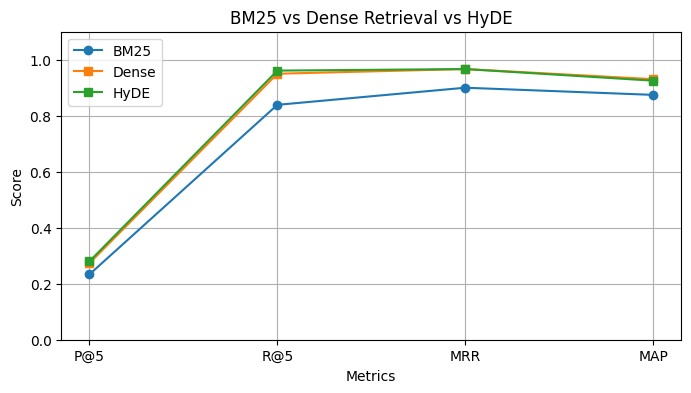

In [15]:
# 시각화
import matplotlib.pyplot as plt

metrics = ['P@5', 'R@5', 'MRR', 'MAP']
bm25_vals = [bm25_metrics['P@k'], bm25_metrics['R@k'], bm25_metrics['MRR'], bm25_metrics['MAP']]
dense_vals = [dense_metrics['P@k'], dense_metrics['R@k'], dense_metrics['MRR'], dense_metrics['MAP']]
hyde_vals = [hyde_metrics['P@k'], hyde_metrics['R@k'], hyde_metrics['MRR'], hyde_metrics['MAP']]

x = range(len(metrics))

plt.figure(figsize=(8, 4))
plt.plot(x, bm25_vals, marker='o', label='BM25')
plt.plot(x, dense_vals, marker='s', label='Dense')
plt.plot(x, hyde_vals, marker='s', label='HyDE')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('BM25 vs Dense Retrieval vs HyDE')
plt.legend()
plt.grid()
plt.show()

##### HyDE의 역할과 효과
- HyDE는 쿼리를 “의미가 풍부한 가상문서”로 확장
- Dense가 이미 강력한 경우:
    - 성능을 보완하거나 유지
    - 항상 큰 폭의 개선을 보장하지는 않음
- 하지만 쿼리가 짧거나 모호한 경우, HyDE의 효과는 더욱 커질 가능성 있음

- Dense Retrieval은 의미 기반 검색의 기본 선택지
- HyDE는 다음 상황에서 특히 유용:
    - 짧고 추상적인 쿼리
    - 질문형 질의
    - Recall 개선이 중요한 경우
- 실서비스에서는: Dense + (HyDE / BM25 / Rerank) 조합이 가장 현실적인 접근